In [67]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [68]:
from pathlib import Path
import sys

# Project root
PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

from modules import helpers
from modules import metrics
from modules import read_timeseries as read
from modules import ADCP_quality_flagging as custom
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

In [69]:
# Configuration
start_date = '2023-01-14'
end_date = '2023-01-15'

# model output
dir_model_output = Path(r'C:/Users/karoa/MOHID_internship/MOHID_single_domain/res')
folders = ['Run1']
name = 'layer' 

# ADCP data
dir_ADCP_data = r'C:/Users/karoa/MOHID_internship/MOHID_model_workflow/data/calibration/ADCP_upper_08.csv'


## Calibration against ADCP data

### Reading files

In [70]:
# reading files

# model output
all_results = {folder: read.read_files(folder, name, dir_model_output) for folder in folders}

# ADCP data
ADCP_output = pd.read_csv(dir_ADCP_data)
ADCP_output = ADCP_output.set_index('date')

# Make sure time periods match and choose layer for model output
ADCP_output = ADCP_output.loc[start_date:end_date]
ADCP_output.index = pd.to_datetime(ADCP_output.index)

### Interpolation

In [71]:
# common
layer_depths = {
    50: 0.494025, 49: 1.541375, 48: 2.645665, 47: 3.819495,
    46: 5.078225, 45: 6.440615, 44: 7.929565, 43: 9.573005,
    42: 11.405,   41: 13.46714, 40: 15.81007, 39: 18.49556,
    38: 21.59882, 37: 25.21141,
}

total_depth = 30.0

layer_altitudes = {
    layer: total_depth - depth
    for layer, depth in layer_depths.items()
}

bottom_end = 25.21141  # this is not the actual bottom depth but only the end of the last bin
circular_cols = ("velocity_direction",)

# interpolation for plotting velocity profiles
bins_full = [
    (2.3, 1.8, 2.8),
    (3.3, 2.8, 3.8),
    (4.3, 3.8, 4.8),
    (5.3, 4.8, 5.8),
    (6.3, 5.8, 6.8),
    (7.3, 6.8, 7.8),
    (8.3, 7.8, 8.8),
    (9.3, 8.8, 9.8),
    (10.3, 9.8, 10.8),
    (11.3, 10.8, 11.8),
    (12.3, 11.8, 12.8),
    (13.3, 12.8, 13.8),
    (14.3, 13.8, 14.8),
    (15.3, 14.8, 15.8),
    (16.3, 15.8, 16.8),
    (17.3, 16.8, 17.8),
    (18.3, 17.8, 18.8),
    (19.3, 18.8, 19.8),
    (20.3, 19.8, 20.8),
    (21.3, 20.8, 21.8),
    (22.3, 21.8, 22.8),
    (23.3, 22.8, 23.8),
    (24.3, 23.8, 24.8),
    (25.3, 24.8, 25.8),
]

binned_full = helpers.aggregate_run(
    all_results['Run1'],
    layer_altitudes,
    bins_full,
    bottom_end,
    circular_cols,
)

# interpolation for calculating metrics

bins = [
    ("bottom", 0.0,  2.3),
    ("lower",   2.3,  13.3),
    ("upper",   13.3, 24.3),
    ("surface",  24.3, 25.22),
]

# Aggregate a single run's per-layer DataFrames into depth bins.
binned = helpers.aggregate_run(
    all_results["Run1"],
    layer_depths,
    bins,
    bottom_end,
    circular_cols
)

model_output_lower = binned['lower'].loc[start_date:end_date]
model_output_upper = binned['upper'].loc[start_date:end_date]

### Plotting velocity profiles

could change plot to depth instead

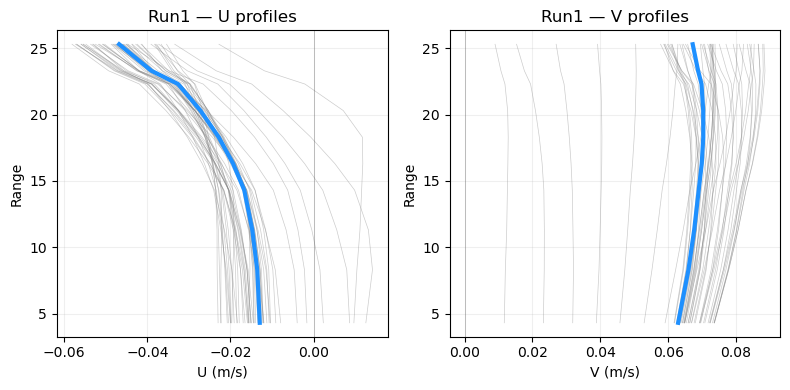

In [72]:
# converting to dataarray
vel_u = metrics.layers_to_dataarray(binned_full, column='velocity_U')
vel_v = metrics.layers_to_dataarray(binned_full, column='velocity_V')


fig, axes = plt.subplots(1, 2, figsize=(8, 4))
custom.plot_profiles(vel_u,
                     range_coord='range',
                     range_slice=(0,25.3),        
                     xlabel='U (m/s)',
                     ylabel='Range',
                     title='Run1 — U profiles',
                     mean_color='blue',
                     ax=axes[0])
custom.plot_profiles(vel_v,
                     range_coord='range',
                     range_slice=(0,25.3),        
                     xlabel='V (m/s)',
                     ylabel='Range',
                     title='Run1 — V profiles',
                     mean_color='blue',
                     ax=axes[1])
plt.show()

In [73]:
# perhaps plot later
#vel_modulus = metrics.layers_to_dataarray(all_results['Run1'], column='velocity_modulus')
#vel_dir = metrics.layers_to_dataarray(all_results['Run1'], column='velocity_direction')

### Calculating metric

In [74]:
metric_fns = [metrics.rmse, metrics.bias, metrics.mss, metrics.pearson_r]

df_all = metrics.compare_runs(
    runs={
        "model_output_upper": model_output_upper,
        "model_output_lower": model_output_lower
    },
    reference=ADCP_output,
    metric_fns=metric_fns,
    columns=['velocity_U', 'velocity_V', 'velocity_direction', 'velocity_modulus'],
)
df_all

,run,variable,rmse,bias,mss,pearson_r
0,model_output_upper,velocity_U,0.044054,0.008857,0.235245,0.079789
1,model_output_upper,velocity_V,0.183505,0.020999,0.150750,-0.116911
2,model_output_upper,velocity_direction,133.222793,74.983910,0.441284,-0.148163
3,model_output_upper,velocity_modulus,0.133411,-0.098415,0.467554,0.288531
4,model_output_lower,velocity_U,0.045409,-0.010891,0.225725,-0.142475
5,model_output_lower,velocity_V,0.182727,0.020718,0.161075,0.036603
6,model_output_lower,velocity_direction,125.710902,61.686278,0.422444,0.122181
7,model_output_lower,velocity_modulus,0.127682,-0.091292,0.476190,0.300677


In [75]:
res_vel_u = df_all[df_all['variable'] == 'velocity_U'].drop(columns='variable').set_index('run')
res_vel_u

,rmse,bias,mss,pearson_r
run,,,,
model_output_upper,0.044054,0.008857,0.235245,0.079789
model_output_lower,0.045409,-0.010891,0.225725,-0.142475
